# Notebook 13 — KymoRoPE: decodificación a trayectorias y comparación con KymoButler

KymoRoPE (notebook 12) no devuelve trayectorias: devuelve tres mapas por píxel — _trackness_
(fondo / estática / móvil), _embedding_ 8-D y _orientación_. Este notebook los convierte en
trayectorias y las mide contra el ground truth y contra KymoButler, con **el mismo harness**
(`evaluacion.evaluar_trayectorias_polilineas`: sólo móviles ≥ 8 px, asociación por fila a ≤ 4 px,
voto por mayoría) que ya midió a Mask2Former y YOLO+SAM3.

**El decode** (`src/axonal_tracking/decodificacion.py`):

```
p(móvil) ≥ umbral            máscara móvil
  → componentes conexas       conectividad PRIMERO
  → mean-shift del embedding  dentro de cada componente
  → seguir en cadenas         una posición por fila, por predicción de pendiente
  → enlazar fragmentos        entre componentes: posición + embedding
  → línea central → extraer_subpixel
  → largo mínimo 30 filas      las astillas cortas pesan como una traza en el harness
  → suavizado Savitzky-Golay   7 filas, a lo largo de cada trayectoria
  → filtro de movilidad       mismo criterio que el GT del harness
```

**Una versión anterior del decode se descartó por medición.** Cortaba la trayectoria ante
cualquier ambigüedad (dos corridas en una fila) en vez de seguirla. Con trackness **e** identidad
GT — o sea con el decode como única fuente de error — daba 1.37 trayectorias por partícula en
val, peor que KymoButler entero (1.27), y 401 de las 408 partículas fragmentadas eran partículas
que cruzan a otra: en un cruce la otra traza tapa a esta y quedan astillas o filas vacías. El
seguimiento por predicción lo baja a 1.14 con las mismas entradas. Los números de esa versión
quedan en `results/kymorope/decode/val_v1_corte/`.

**Dónde corre cada cosa.** Las corridas largas son scripts, este notebook sólo lee sus salidas:

|                          | comando                                                                                              | salida                                       |
| ------------------------ | ---------------------------------------------------------------------------------------------------- | -------------------------------------------- |
| KymoButler               | `uv run python scripts/evaluar_kymobutler_400.py --split val`                                         | `results/kymobutler/*_val*`                  |
| KymoRoPE, 800 muestras   | `uv run python scripts/evaluar_kymorope.py --split val`                                               | `results/kymorope/decode/val/`               |
| KymoRoPE, afinado en 5k  | `... evaluar_kymorope.py --checkpoint results/kymorope/checkpoints/finetune_5k/checkpoint_final.pt`   | `results/kymorope/decode/val_finetune_5k/`   |
| KymoRoPE, afinado en 33k | `... evaluar_kymorope.py --checkpoint results/kymorope/checkpoints/finetune_33k/checkpoint_final.pt`  | `results/kymorope/decode/val_finetune_33k/`  |

**Qué modelo muestra.** `CORRIDA` en §0 elige automáticamente la etapa más avanzada de la curva
de escala de datos que ya tenga su decode en disco: `"finetune_33k"` (etapa 2: afinado sobre las
33 000 desde el de 5000) y, si todavía no está, `"finetune_5k"` (etapa 1: el de 800 afinado sobre
5000). Se puede fijar a mano; `None` es el de 800. §1b pone las tres etapas lado a lado con el
mismo decode.

**Corridas anteriores, guardadas para comparar** (`results/kymorope/decode/`):

| carpeta | qué es |
| --- | --- |
| `val_2026-09-24_etiquetas4px/` | la corrida **original** del modelo de 800: primer decode, etiquetas de 4 px (y el NB13 ejecutado de ese día) |
| `val_800_2026-09-29/`, `val_finetune_5k_2026-09-29/` | los dos modelos con el decode del 2026-09-29 (antes del largo mínimo y el suavizado) |
| `val_finetune_5k_pico_v1/` | centro por pico de intensidad sin guardas: resultado negativo |
| `val_v1_corte/` | la versión del decode que cortaba en vez de seguir: descartada |

**Todo es val.** El punto de operación del decode se elige acá, sobre val. Test se corre **una sola
vez**, al final, con ese punto fijo: elegirlo mirando test contamina el gate.


In [1]:
import json
import pickle
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D

RAIZ = Path("..").resolve()
sys.path.append(str(RAIZ / "src"))

from axonal_tracking import datos_pixel as dp
from axonal_tracking import decodificacion as dc
from axonal_tracking import etiquetas_deteccion as ed
from axonal_tracking import evaluacion as ev
from axonal_tracking import kymorope as kr

SPLIT = "val"  # test: una sola corrida al final, con el punto de operacion elegido aca
MIN_DESP = ed.MIN_DESPLAZAMIENTO_PX_MOVIL
# que modelo: la etapa mas avanzada de la curva de escala de datos que ya tenga su decode en
# disco -- "finetune_33k" (etapa 2, NB12 §7) o "finetune_5k" (etapa 1). Para ver otra, fijarla
# a mano; None = el de 800 (resultados en decode/val). Cualquier corrida de NB12 §7 evaluada
# con `evaluar_kymorope.py --checkpoint` sirve.
CORRIDA = next(
    (
        c
        for c in ("finetune_33k", "finetune_5k")
        if (RAIZ / "results" / "kymorope" / "decode" / f"{SPLIT}_{c}" / "resumen.json").exists()
    ),
    None,
)
# fila de la grilla a mostrar en §2-§4. None = la que elige la regla del script (min
# id-switch + GT fragm. entre las de F1 a <= 0.01 de la mejor); o fijarla, p.ej.
# "M2_h1.5_w0_enlace40" (enlace estricto) o "M2_h1.5_w0_enlace40_enlace_laxo"
FILA_ELEGIDA = None
DIR_KR = RAIZ / "results" / "kymorope" / "decode" / (SPLIT if CORRIDA is None else f"{SPLIT}_{CORRIDA}")
DIR_KB = RAIZ / "results" / "kymobutler"
CHECKPOINT = (
    RAIZ / "results" / "kymorope" / "checkpoints" / "kymorope_40ep_2026-09-24.pt"
    if CORRIDA is None
    else RAIZ / "results" / "kymorope" / "checkpoints" / CORRIDA / "checkpoint_final.pt"
)
VARIANTE_KB = (
    "solo_moviles_subpixel"  # la comparable: misma ruta de extraccion que KymoRoPE
)

for ruta, comando in (
    (DIR_KR / "resumen.json", f"scripts/evaluar_kymorope.py --split {SPLIT}"),
    (
        DIR_KB / f"resumen_{SPLIT}.json",
        f"scripts/evaluar_kymobutler_400.py --split {SPLIT}",
    ),
):
    if not ruta.exists():
        raise FileNotFoundError(f"Falta {ruta}: correr `uv run python {comando}`")

res_kr = json.loads((DIR_KR / "resumen.json").read_text())
res_kb = json.loads((DIR_KB / f"resumen_{SPLIT}.json").read_text())
PUNTO = FILA_ELEGIDA or res_kr["punto_de_operacion"]
# Un resumen viejo no trae las opciones que se agregaron despues (centro desde la
# mascara y enlace estricto el 2026-09-26, centro por pico el 2026-09-29): esa corrida las tenia apagadas, asi
# que se completan apagadas y §4 reproduce exactamente la corrida que hay en disco.
_params = res_kr["filas"][PUNTO]["params"]
PARAMS_PUNTO = dc.ParametrosDecode(
    **{
        "centro_desde_mascara": False,
        "centro_por_pico": False,
        "margen_enlace": 0.0,
        "max_dist_emb_denso": _params.get("max_dist_emb_enlace", 1.5),
        **_params,
    }
)
print(
    f"{SPLIT}: KymoRoPE {res_kr['n_muestras']} muestras, KymoButler {res_kb['n_muestras']} "
    f"({len(res_kb['fallos'])} fallos)"
)
print(f"modelo: {CORRIDA or '800 muestras'} · fila mostrada: {PUNTO}")
print(f"  la regla del script elige: {res_kr['punto_de_operacion']} ({res_kr['regla']})")

# muestras con su kimografo CRUDO y su GT, compartidas por todas las secciones
escenas = {
    d.name: ev.cargar_escena_sintetica(d)
    for d in sorted((RAIZ / "datasets" / SPLIT).glob("sample_*"))
}


def con_polilineas(ruta_pkl):
    """Escenas + las polilineas guardadas por un script, listas para el harness."""
    with open(ruta_pkl, "rb") as f:
        polis = pickle.load(f)
    return {n: {**escenas[n], "polilineas": polis[n]} for n in polis}


esc_kr = con_polilineas(DIR_KR / f"polilineas_{PUNTO}.pkl")
esc_kb = con_polilineas(DIR_KB / f"polilineas_{SPLIT}_{VARIANTE_KB}.pkl")
tr_kr = pd.read_csv(DIR_KR / f"trayectorias_{PUNTO}.csv")
tr_kb = pd.read_csv(DIR_KB / f"trayectorias_{SPLIT}_{VARIANTE_KB}.csv")

val: KymoRoPE 400 muestras, KymoButler 400 (0 fallos)
modelo: finetune_33k · fila mostrada: M2_h1.5_w0_enlace40
  la regla del script elige: M2_h1.5_w0_enlace40 (min frac_id_switch + frac_gt_fragmentado con track_f1 >= mejor M2 - 0.01)


---

## 1. Tabla principal — KymoButler contra la escalera diagnóstica

Cada fila de KymoRoPE aísla una pieza, para que cada cifra se pueda atribuir:

| fila | trackness | identidad            | qué aísla                                                                           |
| ---- | --------- | -------------------- | ----------------------------------------------------------------------------------- |
| D0   | GT        | GT                   | techo del decode + métrica. **Tiene que dar F1 ≈ 1**: si no, el decode tiene un bug |
| D1   | GT        | ninguna              | lo que da la geometría sola (conectividad + seguimiento por pendiente)              |
| D2   | GT        | embedding del modelo | el embedding aislado                                                                |
| M1   | modelo    | ninguna              | trackness del modelo + geometría                                                    |
| M2   | modelo    | embedding del modelo | el sistema real; barrido de ancho de banda `h` y peso de orientación `w`            |

Todas las filas comparten la base del punto de operación: **largo mínimo 30 filas y suavizado
Savitzky-Golay de 7 filas** (elegidos en val el 2026-09-29). `_enlace40`: con enlace de fragmentos
entre componentes (hueco de hasta 40 filas), siempre con identidad — el enlace sólo geométrico
disparaba el id-switch a 0.17–0.19 en la primera corrida.

**Ablaciones del punto de operación**, apagando una pieza por vez: `_sin_suavizado`, `_min10` /
`_min20` (largo mínimo de antes e intermedio), `_enlace_laxo` (sin el enlace estricto en zonas
densas) y `_antes` (todo apagado: tiene que reproducir la corrida anterior).

**Cómo leer la escalera.** D0 → D1 es lo que se pierde sin identidad; D1 → D2, lo que el
embedding del modelo recupera con la máscara perfecta; D2 → M2, lo que cuesta el trackness del
modelo. El punto de operación (regla en la salida de §0) es la fila M2 con menor
`id-switch + GT fragm.` entre las de F1 a ≤ 0.01 de la mejor.

**KymoButler, dos filas.** `subpixel` pasa sus trayectorias por la misma extracción que KymoRoPE
(rasterizar fino → `extraer_subpixel`): es **la comparable**. `esqueleto` es su salida cruda, a
coordenadas enteras; queda de referencia, porque la ruta de extracción mueve el piso de
`id-switch` (0.005 contra 0.132 en test, `scripts/evaluar_kymobutler_400.py`).

Métricas: `id-switch` = fracción de trayectorias predichas que mezclan dos partículas, e
`id-switch (n)` = cuántas son. **Mirar las dos**: la fracción baja si un método fragmenta más
(más trayectorias limpias en el denominador), así que premia fragmentar;
`fragm./GT` = trayectorias predichas por partícula recuperada (1 = ideal); `GT fragm.` = fracción
de partículas partidas en más de una.


In [2]:
COLUMNAS = {
    "track_f1": "F1",
    "track_precision": "precision",
    "track_recall": "recall",
    "frac_id_switch": "id-switch",
    "id_switch_n": "id-switch (n)",
    "fragmentos_por_gt": "fragm./GT",
    "frac_gt_fragmentado": "GT fragm.",
    "err_pos_um_medio": "err pos (um)",
    "err_vel_um_s_mediana": "err vel med (um/s)",
}
filas = {
    "KymoButler · subpixel (comparable)": res_kb["resultados"][VARIANTE_KB],
    "KymoButler · esqueleto crudo": res_kb["resultados"]["solo_moviles"],
}
for nombre, r in res_kr["filas"].items():
    marca = "  <- punto de operacion" if nombre == PUNTO else ""
    filas[f"KymoRoPE · {nombre}{marca}"] = r
tabla = pd.DataFrame(filas).T
tabla["id_switch_n"] = (tabla.n_polilineas.astype(float) * tabla.frac_id_switch.astype(float)).round()  # aprox.: la tasa viene redondeada
tabla = (
    tabla[list(COLUMNAS)]
    .rename(columns=COLUMNAS)
    .astype(float)
    .round(3)
)
display(tabla)

# Las cuatro barras del gate contra la fila comparable de KymoButler, en val
kb, kr_ = res_kb["resultados"][VARIANTE_KB], res_kr["filas"][PUNTO]
barras = [
    ("track_f1", "F1", ">="),
    ("frac_id_switch", "id-switch", "<"),
    ("fragmentos_por_gt", "fragm./GT", "<="),
    ("err_pos_um_medio", "err pos (um)", "<"),
]
gate = pd.DataFrame(
    [
        {
            "barra": nombre,
            "KymoButler": kb[k],
            "KymoRoPE": kr_[k],
            "KymoRoPE gana": {
                ">=": kr_[k] >= kb[k],
                "<": kr_[k] < kb[k],
                "<=": kr_[k] <= kb[k],
            }[op],
        }
        for k, nombre, op in barras
    ]
).set_index("barra")
print(f"\nGate en {SPLIT} (KymoRoPE = {PUNTO}; KymoButler = {VARIANTE_KB}):")
display(gate)

,F1,precision,recall,id-switch,id-switch (n),fragm./GT,GT fragm.,err pos (um),err vel med (um/s)
KymoButler · subpixel (comparable),0.972,0.999,0.947,0.105,287.0,1.273,0.203,0.032,0.014
KymoButler · esqueleto crudo,0.973,0.999,0.948,0.103,282.0,1.273,0.201,0.053,0.014
KymoRoPE · D0_gt_oraculo,0.996,1.000,0.992,0.028,70.0,1.112,0.090,0.029,0.001
KymoRoPE · D0_gt_oraculo_enlace40,0.997,1.000,0.994,0.019,47.0,1.098,0.080,0.029,0.001
KymoRoPE · D1_gt_sin_embedding,0.981,1.000,0.963,0.190,487.0,1.175,0.142,0.027,0.002
KymoRoPE · D2_gt_embedding,0.988,1.000,0.977,0.065,163.0,1.131,0.095,0.030,0.001
KymoRoPE · M1_sin_embedding,0.972,0.998,0.947,0.192,490.0,1.186,0.150,0.030,0.004
KymoRoPE · M2_h1_w0,0.983,0.997,0.970,0.070,185.0,1.198,0.136,0.035,0.001
KymoRoPE · M2_h1_w0_enlace40,0.986,0.997,0.976,0.071,185.0,1.176,0.121,0.036,0.001
KymoRoPE · M2_h1.5_w0,0.981,0.997,0.965,0.073,184.0,1.147,0.105,0.032,0.001



Gate en val (KymoRoPE = M2_h1.5_w0_enlace40; KymoButler = solo_moviles_subpixel):


,KymoButler,KymoRoPE,KymoRoPE gana
barra,,,
F1,0.972,0.983,True
id-switch,0.105,0.071,True
fragm./GT,1.273,1.128,True
err pos (um),0.032,0.032,False


---

## 1b. Etapas — qué cambió con más datos

El mismo decode (la grilla actual) sobre las tres etapas de la curva de escala de datos, así la
diferencia es **solo** de datos: el de 800 muestras (NB12, 40 épocas), ese afinado sobre 5000
(etapa 1, 8 épocas) y ese afinado sobre las 33 000 (etapa 2, 20 épocas de 5000). Cada uno con
enlace estricto y laxo, porque la regla de selección elige entre los dos por una diferencia dentro
del ruido. Una etapa sin decode en disco se saltea con un aviso.

Debajo de la tabla, la **curva**: cada métrica (enlace estricto) contra la cantidad de muestras de
entrenamiento, en escala logarítmica, con KymoButler como referencia.

Dos filas de referencia:

- **La corrida original del modelo de 800** (2026-09-24): primer decode y etiquetas de 4 px. No es
  comparable fila a fila con las otras — cambió el decode y la definición de móvil —, queda como
  punto de partida.
- **KymoButler + SG-7**: KymoButler con el mismo suavizado que usa el decode de KymoRoPE. El
  Savitzky-Golay es un truco genérico que mejora la posición de cualquier tracker; aplicarlo de un
  solo lado inflaría la ventaja de KymoRoPE.

In [3]:
DECODE = RAIZ / "results" / "kymorope" / "decode"
# etapas de la curva de escala de datos: muestras de train y carpeta de su decode
CURVA = {
    "800": (800, DECODE / SPLIT),
    "5k": (5_000, DECODE / f"{SPLIT}_finetune_5k"),
    "33k": (33_000, DECODE / f"{SPLIT}_finetune_33k"),
}
res_etapa = {
    k: json.loads((d / "resumen.json").read_text())
    for k, (_, d) in CURVA.items()
    if (d / "resumen.json").exists()
}
for k in [k for k in CURVA if k not in res_etapa]:
    print(
        f"etapa {k}: sin decode todavia -> `uv run python scripts/evaluar_kymorope.py --split "
        f"{SPLIT} --checkpoint results/kymorope/checkpoints/finetune_{k}/checkpoint_final.pt`"
    )
res_orig = json.loads((DECODE / "val_2026-09-24_etiquetas4px" / "resumen.json").read_text())

# KymoButler con el MISMO suavizado del decode de KymoRoPE (y el mismo filtro de movilidad)
polis_kb_sg = {
    n: [
        p
        for p in (dc.suavizar_polilinea(q, "sg", 7) for q in e["polilineas"])
        if ev.es_movil_polilinea(p, MIN_DESP)
    ]
    for n, e in esc_kb.items()
}
tr_kb_sg, res_kb_sg = ev.evaluar_trayectorias_polilineas(
    {n: {**escenas[n], "polilineas": ps} for n, ps in polis_kb_sg.items()},
    min_desplazamiento_px=MIN_DESP,
)
res_kb_sg = {**res_kb_sg, **ev.resumen_fragmentacion(tr_kb_sg)}

OP = "M2_h1.5_w0_enlace40"
etapas = {
    "KymoButler": res_kb["resultados"][VARIANTE_KB],
    "KymoButler + SG-7 (referencia)": res_kb_sg,
    "800 · corrida original 24-09 (decode y etiquetas viejos)": res_orig["filas"][
        res_orig["punto_de_operacion"]
    ],
}
for k, r in res_etapa.items():
    etapas[f"{k} · decode actual, enlace estricto"] = r["filas"][OP]
    etapas[f"{k} · decode actual, enlace laxo"] = r["filas"][f"{OP}_enlace_laxo"]
t = pd.DataFrame(etapas).T
t["id_switch_n"] = (t.n_polilineas.astype(float) * t.frac_id_switch.astype(float)).round()  # aprox.: la tasa viene redondeada
COL_ETAPAS = {
    "track_f1": "F1",
    "track_recall": "recall",
    "frac_id_switch": "id-switch",
    "id_switch_n": "id-switch (n)",
    "fragmentos_por_gt": "fragm./GT",
    "frac_gt_fragmentado": "GT fragm.",
    "err_pos_um_medio": "err pos (um)",
    "err_vel_um_s_mediana": "err vel med (um/s)",
}
display(t[list(COL_ETAPAS)].rename(columns=COL_ETAPAS).astype(float).round(3))

,F1,recall,id-switch,id-switch (n),fragm./GT,GT fragm.,err pos (um),err vel med (um/s)
KymoButler,0.972,0.947,0.105,287.0,1.273,0.203,0.032,0.014
KymoButler + SG-7 (referencia),0.971,0.945,0.104,283.0,1.270,0.200,0.029,0.014
800 · corrida original 24-09 (decode y etiquetas viejos),0.977,0.958,0.116,337.0,1.336,0.192,0.049,0.010
"800 · decode actual, enlace estricto",0.970,0.944,0.116,308.0,1.239,0.171,0.041,0.007
"800 · decode actual, enlace laxo",0.970,0.944,0.122,321.0,1.230,0.165,0.041,0.006
"5k · decode actual, enlace estricto",0.977,0.958,0.101,258.0,1.173,0.124,0.038,0.002
"5k · decode actual, enlace laxo",0.978,0.959,0.106,269.0,1.165,0.117,0.038,0.002
"33k · decode actual, enlace estricto",0.983,0.969,0.071,176.0,1.128,0.093,0.032,0.001
"33k · decode actual, enlace laxo",0.983,0.970,0.075,186.0,1.123,0.092,0.033,0.001


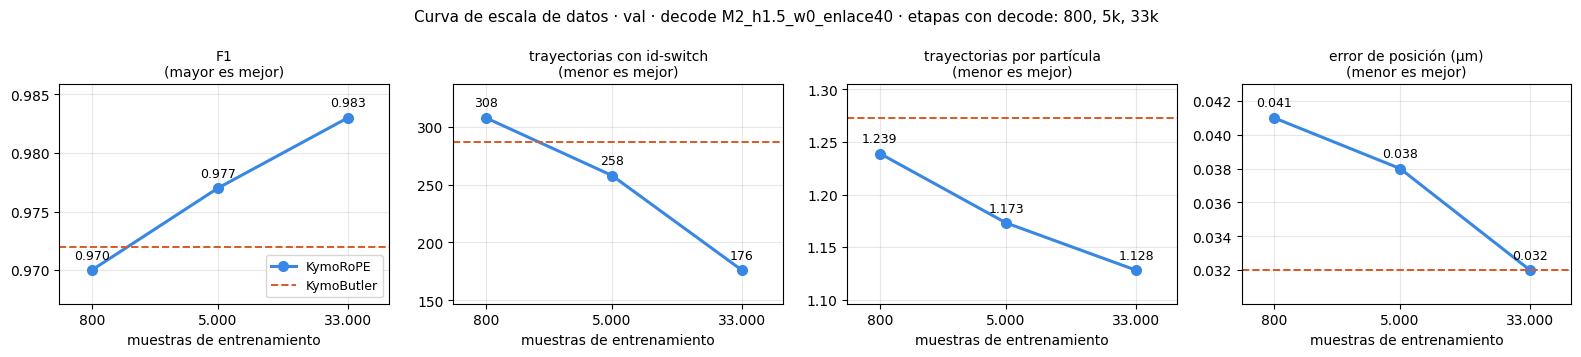

In [4]:
# Curva de escala de datos: cada etapa con el mismo decode (enlace estricto), contra KymoButler
METRICAS_CURVA = {
    "track_f1": ("F1", "mayor es mejor"),
    "id_switch_n": ("trayectorias con id-switch", "menor es mejor"),
    "fragmentos_por_gt": ("trayectorias por partícula", "menor es mejor"),
    "err_pos_um_medio": ("error de posición (µm)", "menor es mejor"),
}


def valor_curva(fila, clave):
    """El conteo de id-switch se reconstruye de la tasa (igual que en la tabla)."""
    if clave == "id_switch_n":
        return round(float(fila["n_polilineas"]) * float(fila["frac_id_switch"]))
    return float(fila[clave])


n_train = [CURVA[k][0] for k in res_etapa]
filas_curva = [res_etapa[k]["filas"][OP] for k in res_etapa]
fila_kb = res_kb["resultados"][VARIANTE_KB]

fig, ejes = plt.subplots(1, len(METRICAS_CURVA), figsize=(16, 3.6))
for ax, (clave, (nombre, sentido)) in zip(ejes, METRICAS_CURVA.items()):
    ys = [valor_curva(f, clave) for f in filas_curva]
    ax.plot(n_train, ys, "o-", color="#3987e5", lw=2.2, ms=7, label="KymoRoPE")
    ax.axhline(valor_curva(fila_kb, clave), color="#d95926", ls="--", lw=1.4, label="KymoButler")
    for x, y in zip(n_train, ys):
        ax.annotate(
            f"{y:.0f}" if clave == "id_switch_n" else f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )
    ax.set_xscale("log")
    ax.set_xticks(n_train, [f"{n:,}".replace(",", ".") for n in n_train])
    ax.minorticks_off()
    ax.set_xlim(500, 60_000)
    ax.margins(y=0.22)  # aire para las etiquetas de valor
    ax.set_title(f"{nombre}\n({sentido})", fontsize=10)
    ax.set_xlabel("muestras de entrenamiento")
    ax.grid(alpha=0.3)
ejes[0].legend(fontsize=9, loc="lower right")
fig.suptitle(
    f"Curva de escala de datos · {SPLIT} · decode {OP} · etapas con decode: {', '.join(res_etapa)}",
    fontsize=11,
)
fig.tight_layout()
plt.show()

---

## 2. Estratificado — dónde gana y dónde pierde cada uno

Dos cortes, los dos sobre las mismas trayectorias de la tabla anterior:

- **Aspect ratio** (`L / T`, terciles de val): la barra 5 del gate, y la que prueba el argumento de
  la arquitectura. KymoRoPE procesa a resolución nativa; KymoButler redimensiona internamente
  (`scale_factor`), y eso debería costarle más en los extremos.
- **Cruce**: partículas cuya traza toca la de otra móvil (`evaluacion.flaggear_cruces_gt`) contra
  las que nunca tocan a nadie. Una partícula aislada no puede sufrir un id-switch por cruce: ahí
  es donde la identidad se decide de verdad.


In [5]:
relacion = pd.Series(
    {n: e["kymo"].shape[1] / e["kymo"].shape[0] for n, e in escenas.items()}
)
terciles = pd.qcut(relacion, 3)
etiquetas_ar = {
    iv: f"{nombre} (L/T {iv.left:.1f}-{iv.right:.1f})"
    for iv, nombre in zip(terciles.cat.categories, ("1 bajo", "2 medio", "3 alto"))
}
estrato_ar = {n: etiquetas_ar[iv] for n, iv in terciles.items()}

cols_estrato = [
    "n_muestras",
    "track_f1",
    "frac_id_switch",
    "fragmentos_por_gt",
    "err_pos_um_medio",
]
por_ar = pd.concat(
    ev.resumen_por_estrato(esc, estrato_ar, min_desplazamiento_px=MIN_DESP).assign(
        metodo=metodo
    )
    for metodo, esc in (("KymoButler", esc_kb), ("KymoRoPE", esc_kr))
)
print("Por aspect ratio:")
display(por_ar.set_index(["estrato", "metodo"])[cols_estrato].sort_index().round(3))

# cruces: particulas GT cuya mascara toca la de otra movil (mismo ancho de mascara que
# usan los otros pipelines, ver docstring de flaggear_cruces_gt)
ambiguos = {
    n: ev.flaggear_cruces_gt(
        e["positions"], e["pixel_scale_um"], e["kymo"].shape, MIN_DESP
    )
    for n, e in escenas.items()
}
por_cruce = pd.concat(
    ev.resumen_por_cruce(tr, ambiguos).assign(metodo=metodo)
    for metodo, tr in (("KymoButler", tr_kb), ("KymoRoPE", tr_kr))
)
print("Por cruce (solo trayectorias con particula GT asignada):")
display(por_cruce.set_index(["grupo", "metodo"]).sort_index().round(3))

Por aspect ratio:


n_muestras  track_f1  frac_id_switch  \
estrato               metodo                                             
1 bajo (L/T 0.7-4.7)  KymoButler         134     0.984           0.185   
                      KymoRoPE           134     0.989           0.130   
2 medio (L/T 4.7-7.8) KymoButler         133     0.970           0.022   
                      KymoRoPE           133     0.985           0.019   
3 alto (L/T 7.8-32.9) KymoButler         133     0.962           0.025   
                      KymoRoPE           133     0.976           0.022   

                                  fragmentos_por_gt  err_pos_um_medio  
estrato               metodo                                           
1 bajo (L/T 0.7-4.7)  KymoButler              1.605             0.038  
                      KymoRoPE                1.310             0.042  
2 medio (L/T 4.7-7.8) KymoButler              1.089             0.026  
                      KymoRoPE                1.019             0.022  
3 alto (L/T 7.8-32.9) KymoButler              1.036             0.025  
                      KymoRoPE                1.003             0.024

Por cruce (solo trayectorias con particula GT asignada):


n_polilineas  n_gt  frac_id_switch  fragmentos_por_gt  \
grupo     metodo                                                              
con cruce KymoButler          1360   872           0.210              1.560   
          KymoRoPE            1150   875           0.153              1.314   
sin cruce KymoButler          1374  1275           0.001              1.078   
          KymoRoPE            1326  1321           0.000              1.004   

                      frac_gt_fragmentado  err_pos_um_medio  
grupo     metodo                                             
con cruce KymoButler                0.396             0.037  
          KymoRoPE                  0.227             0.044  
sin cruce KymoButler                0.071             0.026  
          KymoRoPE                  0.004             0.022

---

## 3. Superposiciones — las trayectorias, dibujadas

Las muestras no se eligen a mano: se cuentan los errores de KymoRoPE por muestra (trayectorias
con id-switch + fragmentos de más + partículas perdidas) y se toman la mediana, el cuantil 90 y
la peor, entre las muestras con al menos dos móviles. `MUESTRAS_EXTRA` agrega nombres puntuales.

Cada panel lleva el prefijo de dónde sale. En los paneles de cada método, las trayectorias
predichas se pintan por resultado contra el GT:

- **blanco**: sigue a una sola partícula;
- **naranja**: id-switch, mezcla dos partículas;
- **azul**: no corresponde a ninguna partícula móvil del GT;
- **verde agua**: partícula del GT que el método no recuperó (se dibuja el GT).

Los puntos marcan dónde empieza y termina cada trayectoria: dos trayectorias blancas con un
punto en el medio de una misma traza son una partícula fragmentada.


In [6]:
import matplotlib.patheffects as pe

# Los tres errores en las tres primeras ranuras categoricas del modo oscuro, validadas
# todos-contra-todos sobre negro (CVD peor par 9.4, vision normal 20.9); acierto en blanco
# neutro. Solo tres colores de error: un cuarto (rojo) quedaba indistinguible del naranja.
C_OK, C_SWITCH, C_SIN_GT, C_PERDIDA = "#ffffff", "#d95926", "#3987e5", "#199e70"
MUESTRAS_EXTRA = []  # nombres puntuales, p.ej. ["sample_00270"]


def leyenda_resultados(ax, con_extremos=True):
    """Leyenda de los paneles de metodo. La linea blanca lleva contorno gris: sin el,
    desaparece sobre el fondo blanco de la figura."""
    contorno = [pe.Stroke(linewidth=3.6, foreground="#898781"), pe.Normal()]
    items = [
        Line2D([], [], color=C_OK, lw=2, path_effects=contorno, label="una particula"),
        Line2D([], [], color=C_SWITCH, lw=2, label="id-switch"),
        Line2D([], [], color=C_SIN_GT, lw=2, label="sin particula GT"),
        Line2D([], [], color=C_PERDIDA, lw=2, label="GT no recuperada"),
    ]
    if con_extremos:
        items.append(
            Line2D(
                [], [], color="#898781", marker="o", ls="", ms=4, label="inicio / fin"
            )
        )
    ax.legend(
        handles=items,
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        borderaxespad=0,
        frameon=False,
        fontsize=8,
    )


def ids_moviles(escena):
    return ed.ids_que_se_mueven(escena["positions"], escena["pixel_scale_um"], MIN_DESP)


def trazas_gt(escena):
    """particle_id -> (frames, columnas) de cada movil GT, cortada donde no es visible."""
    ancho = escena["kymo"].shape[1]
    px = escena["pixel_scale_um"]
    salida = {}
    for pid in ids_moviles(escena):
        sub = escena["positions"][
            escena["positions"]["particle_id"] == pid
        ].sort_values("frame")
        col = (ancho - 1) - sub["pos_um"].to_numpy() / px
        salida[pid] = (
            sub["frame"].to_numpy(),
            np.where(sub["visible"].to_numpy() == 1, col, np.nan),
        )
    return salida


def errores_por_muestra(tr, esc):
    """Errores de identidad de un metodo por muestra: id-switch + fragmentos de mas + perdidas."""
    filas = []
    for n, e in esc.items():
        t = tr[tr.muestra == n]
        asignadas = t[t.gt_id != -1]
        n_gt = len(ids_moviles(e))
        filas.append(
            {
                "muestra": n,
                "moviles": n_gt,
                "id_switch": int(t.id_switch.sum()),
                "fragmentos_de_mas": len(asignadas) - asignadas.gt_id.nunique(),
                "perdidas": n_gt - asignadas.gt_id.nunique(),
            }
        )
    df = pd.DataFrame(filas).set_index("muestra")
    df["errores"] = df.id_switch + df.fragmentos_de_mas + df.perdidas
    return df


def _lienzo(kymo, atenuar=0.45):
    """Kimografo crudo estirado p50-p99.8 (como el resto del repo) y atenuado."""
    lo, hi = np.percentile(kymo, (50, 99.8))
    return np.clip((kymo.astype(float) - lo) / max(hi - lo, 1e-6), 0, 1) * atenuar


def dibujar_metodo(ax, escena, polis, tr_muestra):
    """Trayectorias de un metodo pintadas por resultado; GT no recuperado en C_PERDIDA."""
    por_caja = tr_muestra.set_index("caja")
    for k, poli in enumerate(polis):
        fila = por_caja.loc[k] if k in por_caja.index else None
        if fila is None or fila.gt_id == -1:
            color = C_SIN_GT
        elif fila.id_switch:
            color = C_SWITCH
        else:
            color = C_OK
        ax.plot(poli.col_subpixel, poli.frame, color=color, lw=1.2)
        ax.plot(
            poli.col_subpixel.iloc[[0, -1]],
            poli.frame.iloc[[0, -1]],
            "o",
            color=color,
            ms=3.5,
            mec="black",
            mew=0.4,
        )
    recuperadas = set(tr_muestra.gt_id[tr_muestra.gt_id != -1])
    for pid, (fr, col) in trazas_gt(escena).items():
        if pid not in recuperadas:
            ax.plot(col, fr, color=C_PERDIDA, lw=1.2)


def ver_comparacion(nombre, etiqueta=""):
    """Cuatro paneles apilados con aspecto 1:1 de pixel: entrada, GT, KymoRoPE, KymoButler."""
    escena = escenas[nombre]
    alto_px, ancho_px = escena["kymo"].shape
    esc = min(13.0 / ancho_px, 2.6 / alto_px)
    ancho, alto = ancho_px * esc, alto_px * esc
    izq, der, sup, inf, titulo = 0.7, 2.4, 0.8, 0.5, 0.35
    hueco = max(alto, 1.05)  # la leyenda de la derecha no pisa la fila de abajo
    W, H = izq + ancho + der, sup + 4 * (titulo + hueco) + inf
    fig = plt.figure(figsize=(W, H))
    axs, cursor = [], H - sup
    for _ in range(4):
        cursor -= titulo + alto
        axs.append(fig.add_axes([izq / W, cursor / H, ancho / W, alto / H]))
        cursor -= hueco - alto

    fondo = _lienzo(escena["kymo"])
    axs[0].imshow(fondo / fondo.max(), cmap="gray", vmin=0, vmax=1, aspect="auto")
    axs[0].set_title("ENTRADA · kimografo crudo (p50-p99.8)", loc="left", fontsize=9)

    trazas = trazas_gt(escena)
    axs[1].imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
    for fr, col in trazas.values():
        axs[1].plot(col, fr, color=C_OK, lw=1.2)
    axs[1].set_title(f"GT · {len(trazas)} particulas moviles", loc="left", fontsize=9)

    errores = {}
    for ax, metodo, esc_m, tr_m in (
        (axs[2], "KYMOROPE", esc_kr, tr_kr),
        (axs[3], "KYMOBUTLER", esc_kb, tr_kb),
    ):
        ax.imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
        t = tr_m[tr_m.muestra == nombre]
        dibujar_metodo(ax, escena, esc_m[nombre]["polilineas"], t)
        err = errores_por_muestra(t, {nombre: escena}).iloc[0]
        errores[metodo] = err
        ax.set_title(
            f"{metodo} · {len(esc_m[nombre]['polilineas'])} trayectorias · id-switch {err.id_switch} · "
            f"fragmentos de mas {err.fragmentos_de_mas} · perdidas {err.perdidas}",
            loc="left",
            fontsize=9,
        )
        leyenda_resultados(ax)
    for ax in axs:
        ax.set_xlim(-0.5, ancho_px - 0.5)
        ax.set_ylim(alto_px - 0.5, -0.5)
        ax.set_ylabel("t (frame)", fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axs[:-1]:
        ax.set_xticklabels([])
    axs[-1].set_xlabel("x (px)", fontsize=8)
    fig.suptitle(
        f"{SPLIT} · {nombre} ({etiqueta}) · {alto_px}x{ancho_px} px · {escena['fps']:g} fps · "
        f"KymoRoPE = {PUNTO}, KymoButler = {VARIANTE_KB}",
        x=izq / W,
        y=1 - 0.12 / H,
        ha="left",
        va="top",
        fontsize=10,
    )
    return fig

KymoRoPE                                               \
                      moviles id_switch fragmentos_de_mas perdidas errores   
muestra      caso                                                            
sample_00211 mediana        4         0                 0        0       0   
sample_00252 p90           13         0                 5        1       6   
sample_00271 peor          13         9                13        1      23   

                     KymoButler                                               
                        moviles id_switch fragmentos_de_mas perdidas errores  
muestra      caso                                                             
sample_00211 mediana          4         0                 1        0       1  
sample_00252 p90             13         4                 8        1      13  
sample_00271 peor            13         6                15        0      21

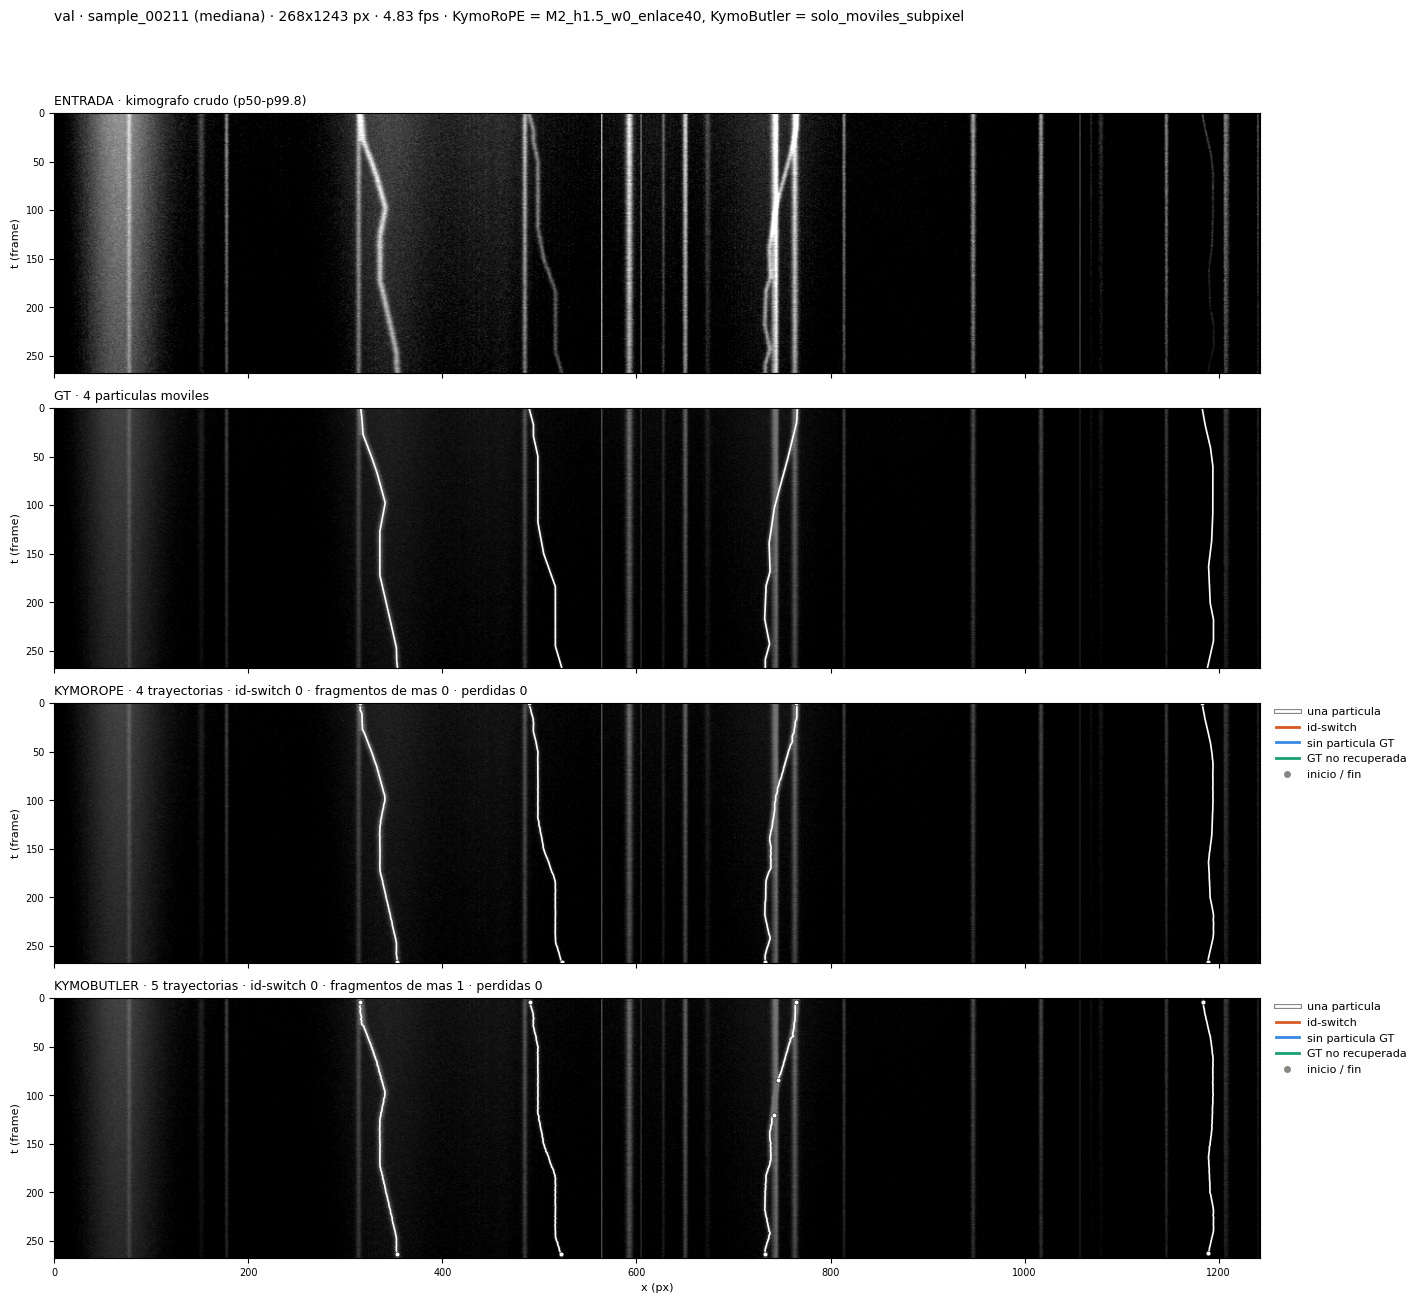

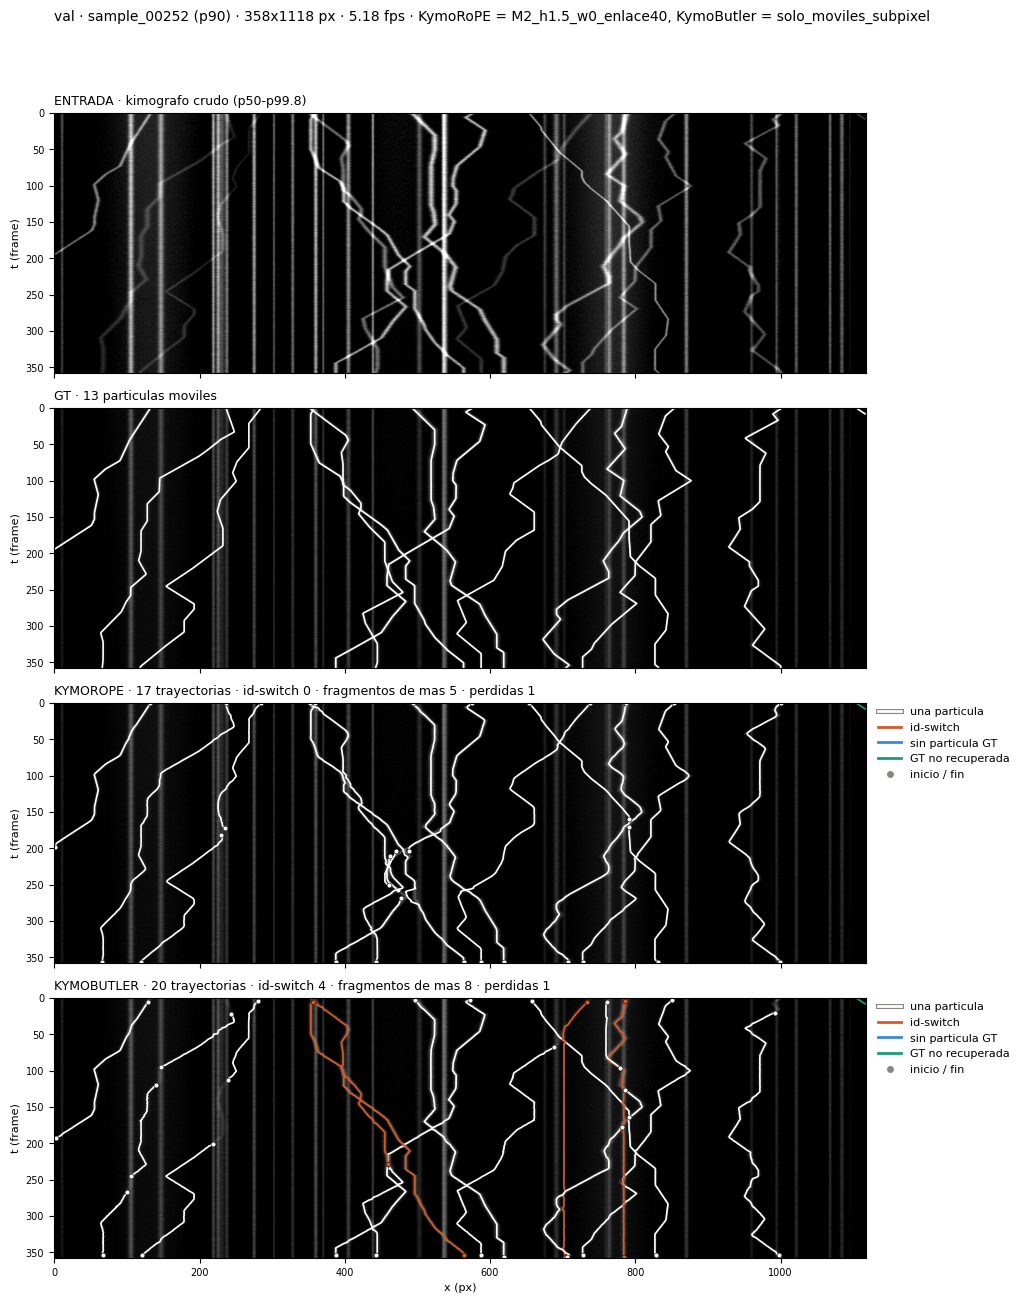

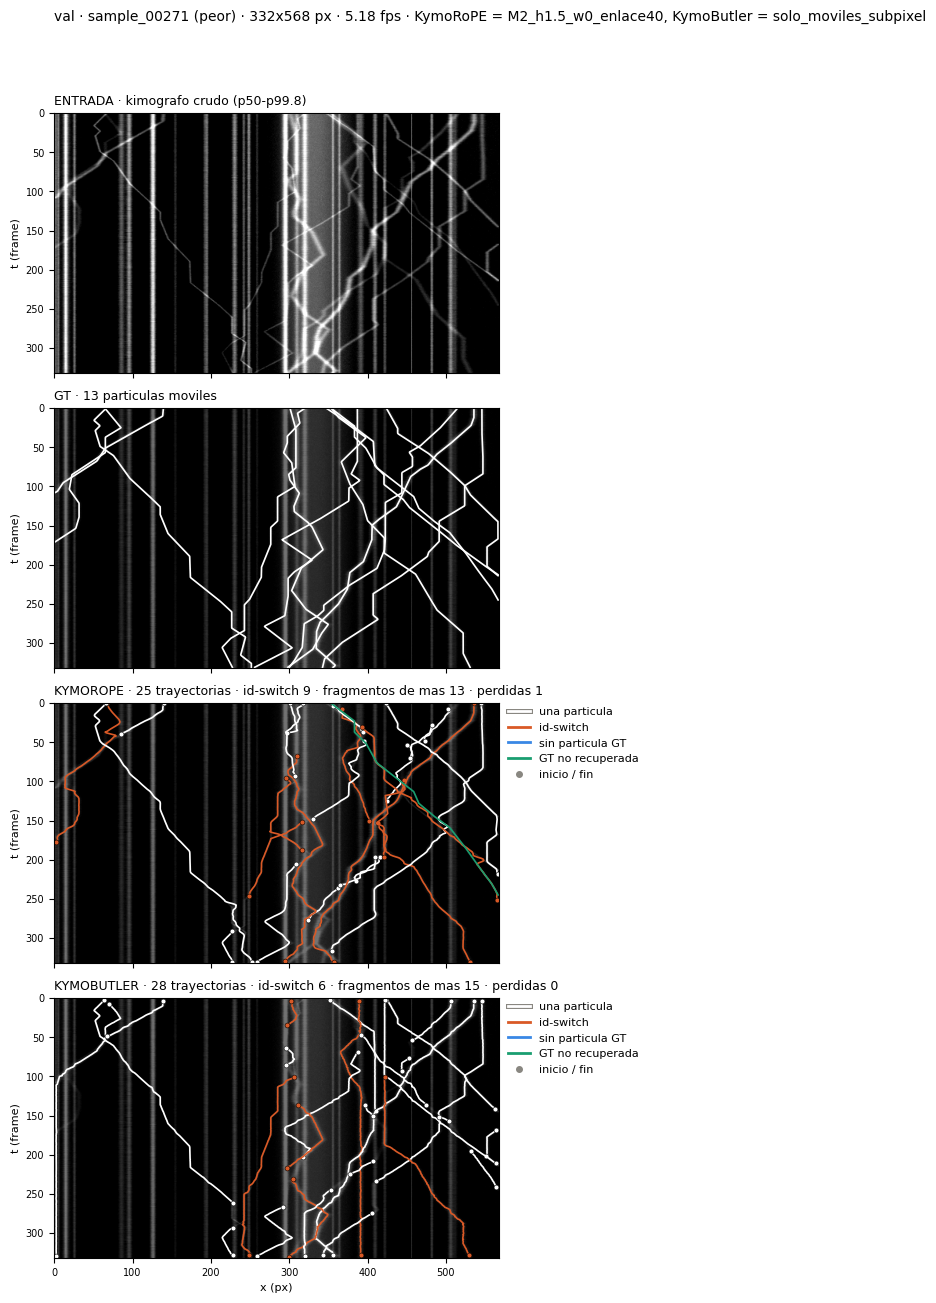

In [7]:
err_kr = errores_por_muestra(tr_kr, esc_kr)
err_kb = errores_por_muestra(tr_kb, esc_kb)
candidatas = err_kr[err_kr.moviles >= 2].sort_values("errores", kind="stable")
elegidas = {
    et: candidatas.index[round(q * (len(candidatas) - 1))]
    for et, q in (("mediana", 0.5), ("p90", 0.9), ("peor", 1.0))
}
elegidas.update({n: n for n in MUESTRAS_EXTRA})
display(
    pd.concat({"KymoRoPE": err_kr, "KymoButler": err_kb}, axis=1)
    .loc[list(elegidas.values())]
    .assign(caso=list(elegidas))
    .set_index("caso", append=True)
)
for etiqueta, nombre in elegidas.items():
    fig = ver_comparacion(nombre, etiqueta)
    plt.show()
    plt.close(fig)

---

## 4. El decode por dentro, sobre una muestra

Lo que hace `decodificar` en cada paso, en vivo (un forward del modelo). Útil para entender de
dónde sale un error de las superposiciones de arriba: ¿la máscara móvil vino cortada, el
agrupamiento fundió dos trazas, o el enlace unió fragmentos equivocados?


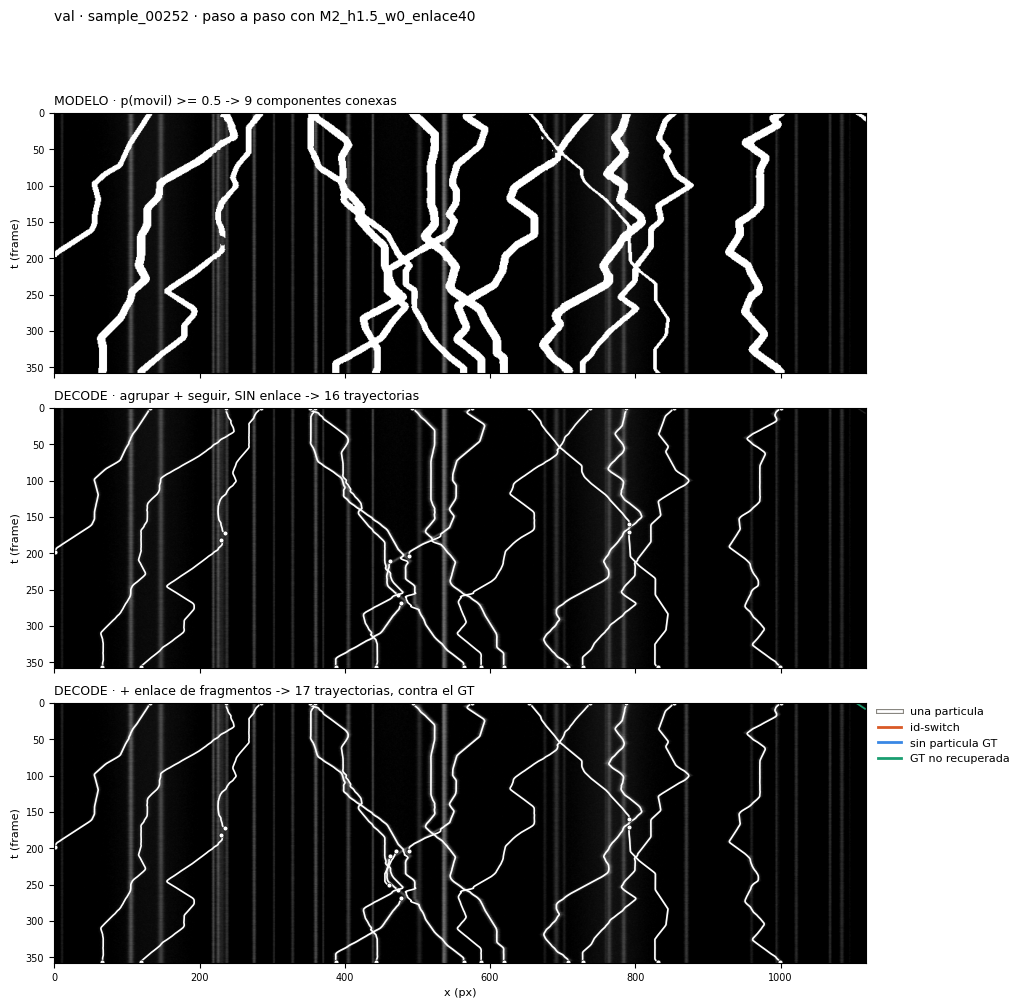

In [8]:
from scipy.ndimage import label

MUESTRA_PASO = elegidas["p90"]  # cualquier nombre de val sirve

ck = torch.load(CHECKPOINT, map_location=kr.dispositivo_preferido(), weights_only=False)
modelo = kr.KymoRoPE().to(kr.dispositivo_preferido()).eval()
modelo.load_state_dict(ck["model_state_dict"])
cache = RAIZ / "results" / "kymorope" / "cache" / SPLIT
ds = dp.DatasetKymografos(
    RAIZ / "datasets" / SPLIT, cache_dir=cache if cache.exists() else None
)
muestra = ds[[d.name for d in ds.dirs].index(MUESTRA_PASO)]
escena = escenas[MUESTRA_PASO]
with torch.no_grad():
    mapas = dc.mapas_desde_salida(modelo([muestra])[0])

mascara = mapas.p_movil >= PARAMS_PUNTO.umbral_movil
_, n_componentes = label(mascara, structure=np.ones((3, 3), int))
sin_enlace = dc.decodificar(
    mapas, escena["kymo"], replace(PARAMS_PUNTO, max_hueco_enlace=0)
)
con_enlace = dc.decodificar(mapas, escena["kymo"], PARAMS_PUNTO)
tr_paso, _ = ev.evaluar_trayectorias_polilineas(
    {MUESTRA_PASO: {**escena, "polilineas": con_enlace}}, min_desplazamiento_px=MIN_DESP
)

alto_px, ancho_px = escena["kymo"].shape
esc = min(13.0 / ancho_px, 2.6 / alto_px)
ancho, alto = ancho_px * esc, alto_px * esc
izq, der, sup, inf, titulo = 0.7, 2.4, 0.8, 0.5, 0.35
hueco = max(alto, 1.05)
W, H = izq + ancho + der, sup + 3 * (titulo + hueco) + inf
fig = plt.figure(figsize=(W, H))
axs, cursor = [], H - sup
for _ in range(3):
    cursor -= titulo + alto
    axs.append(fig.add_axes([izq / W, cursor / H, ancho / W, alto / H]))
    cursor -= hueco - alto

fondo = _lienzo(escena["kymo"])
lz = np.repeat(fondo[..., None], 3, axis=-1)
lz[mascara] = mcolors.to_rgb(C_OK)
axs[0].imshow(lz, aspect="auto")
axs[0].set_title(
    f"MODELO · p(movil) >= {PARAMS_PUNTO.umbral_movil} -> {n_componentes} componentes conexas",
    loc="left",
    fontsize=9,
)
axs[1].imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
for poli in sin_enlace:
    axs[1].plot(poli.col_subpixel, poli.frame, color=C_OK, lw=1.2)
    axs[1].plot(
        poli.col_subpixel.iloc[[0, -1]],
        poli.frame.iloc[[0, -1]],
        "o",
        color=C_OK,
        ms=3.5,
        mec="black",
        mew=0.4,
    )
axs[1].set_title(
    f"DECODE · agrupar + seguir, SIN enlace -> {len(sin_enlace)} trayectorias",
    loc="left",
    fontsize=9,
)
axs[2].imshow(fondo, cmap="gray", vmin=0, vmax=1, aspect="auto")
dibujar_metodo(axs[2], escena, con_enlace, tr_paso)
axs[2].set_title(
    f"DECODE · + enlace de fragmentos -> {len(con_enlace)} trayectorias, contra el GT",
    loc="left",
    fontsize=9,
)
leyenda_resultados(axs[2], con_extremos=False)
for ax in axs:
    ax.set_xlim(-0.5, ancho_px - 0.5)
    ax.set_ylim(alto_px - 0.5, -0.5)
    ax.set_ylabel("t (frame)", fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axs[:-1]:
    ax.set_xticklabels([])
axs[-1].set_xlabel("x (px)", fontsize=8)
fig.suptitle(
    f"{SPLIT} · {MUESTRA_PASO} · paso a paso con {PUNTO}",
    x=izq / W,
    y=1 - 0.12 / H,
    ha="left",
    va="top",
    fontsize=10,
)
plt.show()
plt.close(fig)

---

## 5. Lectura — val, 400 muestras (corridas del 2026-10-02)

_Texto fijo, escrito sobre esas corridas; las tablas de arriba son las vivas. Modelo: el de la
etapa 2 (`finetune_33k`), fila `M2_h1.5_w0_enlace40` (enlace estricto), que ahora es también la que
elige la regla del script. Lecturas anteriores: la del modelo de 5000 (2026-09-30) en
`results/kymorope/decode/val_finetune_5k/lectura_nb13_2026-09-30.md`, y la de la primera corrida
del modelo de 800 (2026-09-24) en
`results/kymorope/decode/val_2026-09-24_etiquetas4px/nb13_ejecutado_2026-09-24.ipynb`._

**Val es representativo.** KymoButler en val (F1 0.972, id-switch 0.105, 1.273 trayectorias por
partícula, 0.032 µm) calca las barras del gate, que son su cifra de test (0.968 / 0.103 / 1.282 /
0.032).

**El decode no es el cuello de botella.** Con trackness e identidad GT (D0): F1 0.996, id-switch
0.028, 1.11 trayectorias por partícula y 0.029 µm de posición, mejor que KymoButler. Es el mismo
techo que con los modelos anteriores: todo lo que mejoró abajo es del modelo.

### La curva de escala de datos: 800 → 5000 → 33 000 (§1b, enlace estricto)

|                                    |  KymoButler |         800 |          5k |             **33k** |
| ---------------------------------- | ----------: | ----------: | ----------: | ------------------: |
| F1                                 |       0.972 |       0.970 |       0.977 |           **0.983** |
| recall                             |       0.947 |       0.944 |       0.958 |           **0.969** |
| id-switch (tasa · trayectorias)    | 0.105 · 287 | 0.116 · 308 | 0.101 · 258 |     **0.071 · 176** |
| trayectorias por partícula         |       1.273 |       1.239 |       1.173 |           **1.128** |
| partículas fragmentadas            |       0.203 |       0.171 |       0.124 |           **0.093** |
| error de posición (µm)             |   **0.032** |       0.041 |       0.038 |               0.032 |
| error de velocidad, mediana (µm/s) |       0.014 |       0.007 |       0.002 |           **0.001** |

Cada etapa mejoró todas las métricas, y la curva de §1b no muestra todavía que se aplane. La
escalera reparte el mérito entre las dos cabezas:

- **embedding** (D2, máscara GT + embedding del modelo): id-switch 0.110 → 0.089 → 0.065;
- **trackness** (M1, sin embedding): recall 0.932 → 0.944 → 0.947 y 1.283 → 1.226 → 1.186
  trayectorias por partícula.

**Contra el gate** (barras fijadas antes de entrenar):

- **pasa** F1 (0.983 ≥ 0.968) y trayectorias por partícula (1.128 ≤ 1.282);
- **pasa** el id-switch, que con el modelo de 5000 era un empate: 0.071 es claramente menos que
  0.103, con 176 trayectorias con switch contra 287 de KymoButler (−39 %);
- **empata** la posición: 0.0323 µm contra 0.0319 de KymoButler, y la barra pide < 0.032. Pesando
  por filas, KymoRoPE queda adelante (0.0299 contra 0.0319);
- **por forma de kimograma**, gana identidad y fragmentación en los tres tercios; la posición la
  gana en los medios y los anchos y la pierde en los angostos.

**Qué fila.** La regla del script ya elige la estricta (la laxa: 0.075 · 186, 1.123, 0.033 µm), así
que la regla y la recomendación coinciden. `h=1` dejó de convenir: mismo id-switch (0.071 · 185)
con más fragmentos (1.176) y peor posición (0.036). `h=2` funde partículas (0.107 · 262). Sumar la
orientación al mean-shift (`w1`) tampoco ayuda con este modelo: 0.075 · 189 contra 0.073 · 184 sin
ella (las dos sin enlace).

### Dónde gana y dónde pierde (33k, enlace estricto)

|                             | sin cruce: KymoButler | sin cruce: 33k | con cruce: KymoButler | con cruce: 33k |
| --------------------------- | --------------------: | -------------: | --------------------: | -------------: |
| id-switch (tasa · trayect.) |             0.001 · 1 |  **0.000 · 0** |           0.210 · 286 | **0.153 · 176** |
| trayectorias por partícula  |                 1.078 |      **1.004** |                 1.560 |      **1.314** |
| partículas fragmentadas     |                 0.071 |      **0.004** |                 0.396 |      **0.227** |
| error de posición (µm)      |                 0.026 |      **0.022** |             **0.037** |          0.044 |

- **Fuera de los cruces** (60 % de las partículas): ningún cambio de identidad y mejor en todo,
  incluida la posición.
- **En los cruces**, lo que antes perdía o empataba ahora es la ventaja principal: 110
  trayectorias con switch menos y mucha menos fragmentación. Lo único que sigue perdiendo es la
  **posición en los cruces** (0.044 contra 0.037): es la brecha que queda, y está entera ahí.

Por forma (terciles de L/T = columnas / frames; KymoButler / 33k):

|                             | angostos (0.7–4.7)          | medios (4.7–7.8)          | anchos (7.8–32.9)         |
| --------------------------- | --------------------------- | ------------------------- | ------------------------- |
| id-switch (tasa · trayect.) | 0.185 · 254 / **0.130 · 148** | 0.022 · 11 / **0.019 · 9** | 0.025 · 22 / **0.022 · 19** |
| trayectorias por partícula  | 1.605 / **1.310**           | 1.089 / **1.019**         | 1.036 / **1.003**         |
| error de posición (µm)      | **0.038** / 0.042           | 0.026 / **0.022**         | 0.025 / **0.024**         |

### El decode con el modelo de 33k (ablaciones de §1, una pieza apagada por vez)

| pieza | sin ella | con ella |
| --- | --- | --- |
| largo mínimo 30 filas (vs 10) | 1.197 trayect./partícula · 0.038 µm | 1.128 · 0.032 µm |
| suavizado Savitzky-Golay, 7 filas | 0.035 µm · 184 con switch | 0.032 µm · 176 |
| enlace estricto en zonas densas (vs laxo) | 0.075 · 186 · 1.123 | 0.071 · 176 · 1.128 |
| todo apagado (`_antes`) | 0.073 · 194 · 1.196 · 0.042 µm | — |

Con el largo mínimo, las trayectorias con switch no cambian (177 → 176) pero la tasa sube de 0.067
a 0.071 sólo por el denominador.

**Posición, comparada con justicia.** El suavizado es genérico: KymoButler con el mismo SG-7 baja
a 0.0288 µm por trayectoria y 0.0291 por fila. Contra esa versión, KymoRoPE (0.0323 / 0.0299)
queda ~0.001 µm atrás por fila, alrededor del 1 % de un píxel, y ~0.0035 por trayectoria.

**Entrenamiento de la etapa 2.** La pérdida de validación por píxel bajó de 0.265 a 0.171 (la etapa
1 terminó en 0.277, con las mismas etiquetas y el mismo val), sin señal de sobreajuste, y se aplana
desde la época ~15, cuando el OneCycle ya está bajando la tasa a cero. No es el criterio de
decisión: lo es el harness de trayectorias de arriba.

### Advertencias para la tesis

- **Todo se eligió en val** (fila, largo mínimo, suavizado), así que los márgenes son optimistas.
  Test se corre **una sola vez**, al final, con el modelo de 33k y la fila estricta fijos.
- **La tasa de id-switch premia fragmentar**: reportar también el conteo (176 contra 287).
- El error de posición del harness promedia **por trayectoria**; reportar también el pesado por
  filas.

### Próximos pasos

1. **Test**, una vez: KymoRoPE (33k, `M2_h1.5_w0_enlace40`) y KymoButler sobre las mismas 400.
2. **Posición en los cruces**: es la única barra que no se gana, y la brecha está toda ahí.
3. **¿Más datos o épocas?** Las cuatro métricas de la curva siguen bajando de 5000 a 33 000.